## Penjelasan Dataset yang digunakan

In [ ]:
## Berikan penjelasan terkait data apa yang digunakan diantaranya:
# 1. Kasus yang diambil
# 2. Penjelasan setiap kolomnya
# 3. Import library
# 4. Load data

### 1. Kasus yang diambil
Dataset ini berisi ulasan pelanggan Starbucks yang mencakup nama pengguna, lokasi, tanggal, rating, teks ulasan, dan tautan gambar.  
Tujuannya adalah untuk menganalisis ulasan, melihat distribusi rating, serta menemukan kata-kata yang paling sering digunakan pelanggan.

### 2. Penjelasan setiap kolom
- **name** : Nama pengguna yang memberi ulasan  
- **location** : Lokasi pengguna (biasanya kota, negara bagian, atau negara)  
- **Date** : Tanggal ulasan dibuat  
- **Rating** : Nilai rating dari 1 sampai 5  
- **Review** : Teks ulasan pelanggan  
- **Image_Links** : Tautan gambar produk / lokasi atau “No Images”


In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supaya grafik langsung tampil di notebook
%matplotlib inline

# Atur gaya tampilan grafik
sns.set(style="whitegrid")

print("✅ Library berhasil di-import")


✅ Library berhasil di-import


In [5]:
from google.colab import files

# Jalankan perintah upload
uploaded = files.upload()


Saving reviews_data.csv to reviews_data.csv


In [6]:
df = pd.read_csv("reviews_data.csv")
df.head()


,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


## Data Understanding

In [ ]:
# 1. Jumlah baris data
# 2. Panjang rata-rata setiap baris
# 3. Cek data duplikasi
# 4. Cek data kosong
# 5. Distribusi data menggunakan bar chart, line chart atau word cloud, seperti kata yang sering muncul.

In [7]:
#Jumlah baris
print (df)

          name            location                     Date  Rating  \
0        Helen   Wichita Falls, TX  Reviewed Sept. 13, 2023     5.0   
1     Courtney          Apopka, FL   Reviewed July 16, 2023     5.0   
2     Daynelle   Cranberry Twp, PA    Reviewed July 5, 2023     5.0   
3       Taylor         Seattle, WA    Reviewed May 26, 2023     5.0   
4      Tenessa         Gresham, OR   Reviewed Jan. 22, 2023     5.0   
..         ...                 ...                      ...     ...   
845      Becky    Agoura Hills, CA   Reviewed July 13, 2006     NaN   
846        Bob        Goodrich, MI    Reviewed Jan. 3, 2005     NaN   
847       Erik  Valley Village, CA    Reviewed Nov. 5, 2004     NaN   
848     Andrew       Fallbrook, CA   Reviewed Oct. 20, 2004     NaN   
849  Christian          Ramsey, NJ   Reviewed July 19, 2000     NaN   

                                                Review  \
0    Amber and LaDonna at the Starbucks on Southwes...   
1    ** at the Starbucks by the

In [8]:
# Menggabungkan semua kolom menjadi satu string per baris, lalu hitung panjangnya
df['row_length'] = df.astype(str).apply(lambda x: len(' '.join(x)), axis=1)

# Hitung rata-rata panjang baris
average_length = df['row_length'].mean()

print(f"Panjang rata-rata setiap baris data adalah: {average_length:.2f} karakter")


Panjang rata-rata setiap baris data adalah: 539.51 karakter


In [10]:
# Mengecek jumlah data duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")


Jumlah data duplikat: 1


In [12]:
# Hapus baris yang duplikat
df = df.drop_duplicates().reset_index(drop=True)

# Cek ulang apakah masih ada duplikat
print("Jumlah duplikat setelah dibersihkan:", df.duplicated().sum())


Jumlah duplikat setelah dibersihkan: 0


In [13]:
# Mengecek ulang jumlah data duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat saat ini: {duplicate_count}")


Jumlah data duplikat saat ini: 0


In [15]:
# Cek jumlah data kosong (NaN) di setiap kolom
print("Jumlah data kosong di setiap kolom:\n")
print(df.isnull().sum())

# Cek total data kosong di seluruh dataset
total_kosong = df.isnull().sum().sum()
print(f"\nTotal seluruh data kosong: {total_kosong}")

# Cek persentase data kosong per kolom
print("\nPersentase data kosong per kolom (%):\n")
print((df.isnull().mean() * 100).round(2))

Jumlah data kosong di setiap kolom:

name             0
location         0
Date             0
Rating         144
Review           0
Image_Links      0
row_length       0
dtype: int64

Total seluruh data kosong: 144

Persentase data kosong per kolom (%):

name            0.00
location        0.00
Date            0.00
Rating         16.96
Review          0.00
Image_Links     0.00
row_length      0.00
dtype: float64


In [16]:
!pip install wordcloud --quiet
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [17]:
# Gabungkan semua review menjadi satu teks panjang
all_text = " ".join(df["Review"].astype(str))

print("Jumlah total karakter teks:", len(all_text))
print("Contoh potongan teks:\n")
print(all_text[:500])  # tampilkan 500 karakter pertama


Jumlah total karakter teks: 401239
Contoh potongan teks:

Amber and LaDonna at the Starbucks on Southwest Parkway are always so warm and welcoming. There is always a smile in their voice when they greet you at the drive-thru. And their customer service is always spot-on, they always get my order right and with a smile. I would actually give them more than 5 stars if they were available. ** at the Starbucks by the fire station on 436 in Altamonte Springs, FL made my day and finally helped me figure out the way to make my drink so I’d love it. She took t


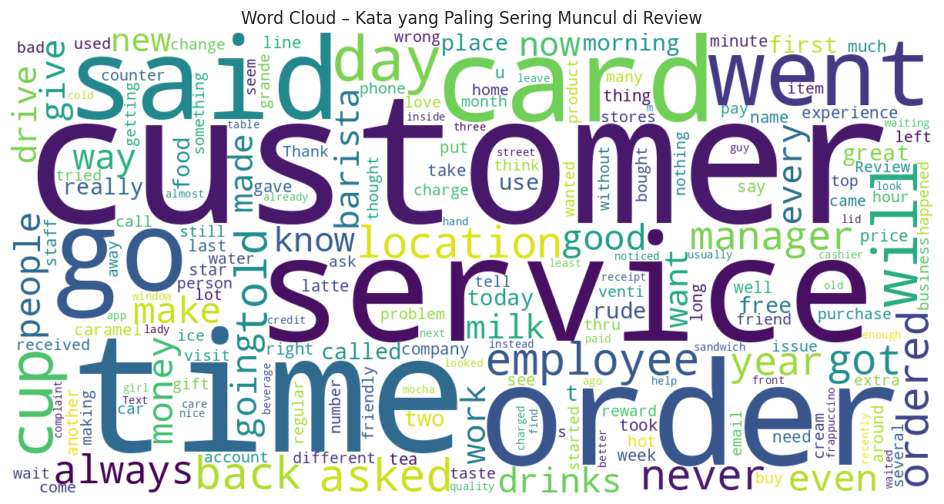

In [18]:
# Daftar stopwords (kata umum yang akan diabaikan, seperti 'the', 'and', dll)
stopwords = set(STOPWORDS)
stopwords.update(["starbucks", "coffee", "drink", "store", "one", "like"])  # kamu bisa tambah kata lain di sini

# Buat word cloud
wordcloud = WordCloud(width=1200, height=600,
                      background_color='white',
                      stopwords=stopwords,
                      collocations=False).generate(all_text)

# Tampilkan word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud – Kata yang Paling Sering Muncul di Review")
plt.show()


In [21]:
import nltk

In [22]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

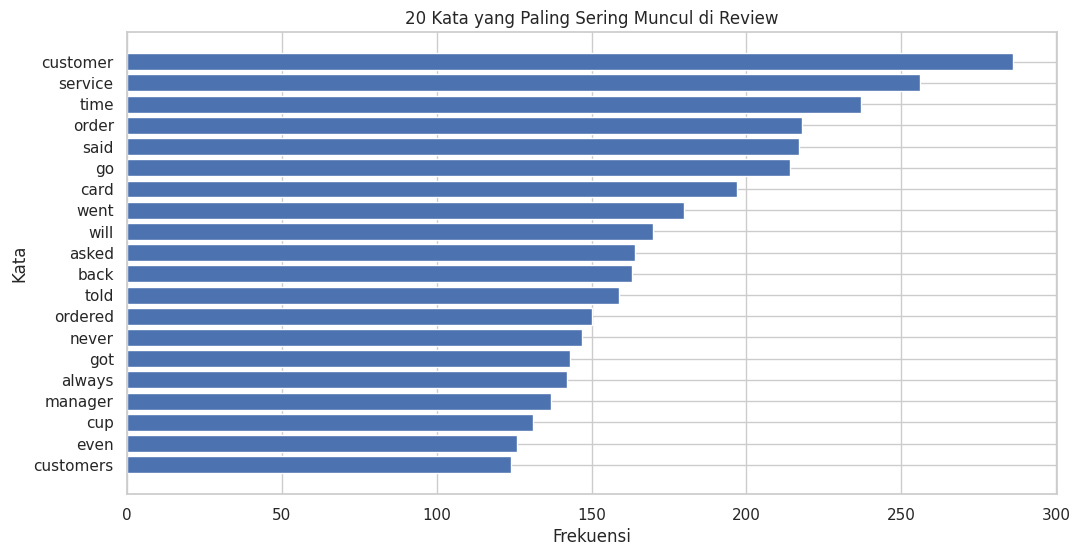

In [24]:
from collections import Counter
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize

# Tokenisasi semua kata
tokens = word_tokenize(all_text.lower())

# Hapus stopwords dan tanda baca
tokens = [word for word in tokens if word.isalpha() and word not in stopwords]

# Hitung frekuensi kata
word_freq = Counter(tokens)

# Ambil 20 kata paling sering muncul
common_words = word_freq.most_common(20)

# Pisahkan kata dan jumlahnya
words, counts = zip(*common_words)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.barh(words[::-1], counts[::-1])
plt.title("20 Kata yang Paling Sering Muncul di Review")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.show()


## Data Text Processing

In [ ]:
# 1. Tokenisasi
# 2. Lemmatization
# 3. Stemming
# 4. Stopword removal (Tanda baca, angka dan kata)
# 5. Text Normalisasi
# 6. Matrix correlation (opsional)
# 7. Text Vektorisasi

In [25]:
# Import modul yang dibutuhkan
import nltk
from nltk.tokenize import word_tokenize

# Pastikan paket 'punkt' sudah diunduh
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
# Tokenisasi setiap review
df['tokens'] = df['Review'].astype(str).apply(word_tokenize)

# Tampilkan 5 contoh hasil tokenisasi
df[['Review', 'tokens']].head()

,Review,tokens
0,Amber and LaDonna at the Starbucks on Southwes...,"[Amber, and, LaDonna, at, the, Starbucks, on, ..."
1,** at the Starbucks by the fire station on 436...,"[*, *, at, the, Starbucks, by, the, fire, stat..."
2,I just wanted to go out of my way to recognize...,"[I, just, wanted, to, go, out, of, my, way, to..."
3,Me and my friend were at Starbucks and my card...,"[Me, and, my, friend, were, at, Starbucks, and..."
4,I’m on this kick of drinking 5 cups of warm wa...,"[I, ’, m, on, this, kick, of, drinking, 5, cup..."


In [27]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

# Download data pendukung untuk lemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

# Buat objek lemmatizer
lemmatizer = WordNetLemmatizer()

# Lakukan lemmatization untuk setiap token di setiap review
df['lemmatized'] = df['tokens'].apply(lambda tokens: [lemmatizer.lemmatize(word.lower()) for word in tokens])

# Tampilkan hasil contoh
df[['tokens', 'lemmatized']].head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,tokens,lemmatized
0,"[Amber, and, LaDonna, at, the, Starbucks, on, ...","[amber, and, ladonna, at, the, starbucks, on, ..."
1,"[*, *, at, the, Starbucks, by, the, fire, stat...","[*, *, at, the, starbucks, by, the, fire, stat..."
2,"[I, just, wanted, to, go, out, of, my, way, to...","[i, just, wanted, to, go, out, of, my, way, to..."
3,"[Me, and, my, friend, were, at, Starbucks, and...","[me, and, my, friend, were, at, starbucks, and..."
4,"[I, ’, m, on, this, kick, of, drinking, 5, cup...","[i, ’, m, on, this, kick, of, drinking, 5, cup..."


In [28]:
from nltk.stem import PorterStemmer

# Buat objek stemmer
stemmer = PorterStemmer()

# Terapkan stemming untuk setiap token
df['stemmed'] = df['tokens'].apply(lambda tokens: [stemmer.stem(word.lower()) for word in tokens])

# Tampilkan hasil contoh
df[['tokens', 'stemmed']].head()


,tokens,stemmed
0,"[Amber, and, LaDonna, at, the, Starbucks, on, ...","[amber, and, ladonna, at, the, starbuck, on, s..."
1,"[*, *, at, the, Starbucks, by, the, fire, stat...","[*, *, at, the, starbuck, by, the, fire, stati..."
2,"[I, just, wanted, to, go, out, of, my, way, to...","[i, just, want, to, go, out, of, my, way, to, ..."
3,"[Me, and, my, friend, were, at, Starbucks, and...","[me, and, my, friend, were, at, starbuck, and,..."
4,"[I, ’, m, on, this, kick, of, drinking, 5, cup...","[i, ’, m, on, thi, kick, of, drink, 5, cup, of..."


In [29]:
import string
from nltk.corpus import stopwords
import nltk

# Download stopwords bahasa Inggris
nltk.download('stopwords')

# Ambil daftar stopwords bahasa Inggris
stop_words = set(stopwords.words('english'))

# Hapus stopwords, tanda baca, dan angka
def clean_tokens(tokens):
    cleaned = []
    for word in tokens:
        word = word.lower()  # ubah ke huruf kecil
        # hanya ambil kata alfabet (buang angka dan tanda baca)
        if word.isalpha() and word not in stop_words:
            cleaned.append(word)
    return cleaned

# Terapkan fungsi ke kolom tokens
df['clean_tokens'] = df['tokens'].apply(clean_tokens)

# Lihat hasilnya
df[['tokens', 'clean_tokens']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,tokens,clean_tokens
0,"[Amber, and, LaDonna, at, the, Starbucks, on, ...","[amber, ladonna, starbucks, southwest, parkway..."
1,"[*, *, at, the, Starbucks, by, the, fire, stat...","[starbucks, fire, station, altamonte, springs,..."
2,"[I, just, wanted, to, go, out, of, my, way, to...","[wanted, go, way, recognize, starbucks, employ..."
3,"[Me, and, my, friend, were, at, Starbucks, and...","[friend, starbucks, card, work, thankful, work..."
4,"[I, ’, m, on, this, kick, of, drinking, 5, cup...","[kick, drinking, cups, warm, water, work, inst..."


In [30]:
# Contoh kamus normalisasi (bisa kamu tambah sesuai kebutuhan)
normalization_dict = {
    "u": "you",
    "r": "are",
    "ur": "your",
    "btw": "by the way",
    "idk": "i do not know",
    "thx": "thanks",
    "pls": "please",
    "omg": "oh my god",
    "lol": "laughing out loud",
    "gr8": "great",
    "luv": "love",
    "w/": "with",
    "w/o": "without"
}

# Fungsi normalisasi kata berdasarkan kamus di atas
def normalize_tokens(tokens):
    normalized = []
    for word in tokens:
        word_lower = word.lower()
        if word_lower in normalization_dict:
            normalized.append(normalization_dict[word_lower])
        else:
            normalized.append(word_lower)
    return normalized

# Terapkan ke kolom clean_tokens
df['normalized_tokens'] = df['clean_tokens'].apply(normalize_tokens)

# Lihat hasilnya
df[['clean_tokens', 'normalized_tokens']].head()


,clean_tokens,normalized_tokens
0,"[amber, ladonna, starbucks, southwest, parkway...","[amber, ladonna, starbucks, southwest, parkway..."
1,"[starbucks, fire, station, altamonte, springs,...","[starbucks, fire, station, altamonte, springs,..."
2,"[wanted, go, way, recognize, starbucks, employ...","[wanted, go, way, recognize, starbucks, employ..."
3,"[friend, starbucks, card, work, thankful, work...","[friend, starbucks, card, work, thankful, work..."
4,"[kick, drinking, cups, warm, water, work, inst...","[kick, drinking, cups, warm, water, work, inst..."


Matriks Korelasi:

              Rating  row_length  word_count
Rating      1.000000   -0.329227   -0.323064
row_length -0.329227    1.000000    0.975362
word_count -0.323064    0.975362    1.000000


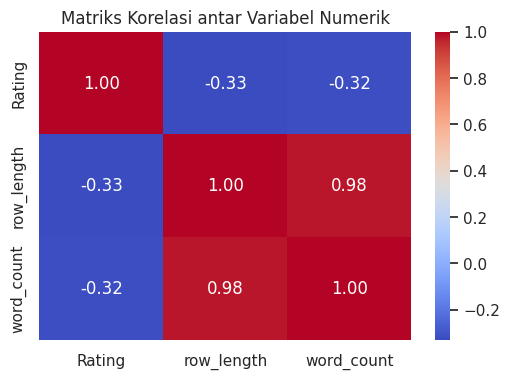

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Buat kolom baru: jumlah kata dalam review
df['word_count'] = df['normalized_tokens'].apply(len)

# Pilih hanya kolom numerik untuk korelasi
numeric_cols = ['Rating', 'row_length', 'word_count']

# Hitung korelasi
corr_matrix = df[numeric_cols].corr()

# Tampilkan matriks korelasi
print("Matriks Korelasi:\n")
print(corr_matrix)

# Visualisasi dengan heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi antar Variabel Numerik")
plt.show()


In [32]:
from sklearn.feature_extraction.text import CountVectorizer

# Gabungkan token hasil normalisasi jadi teks lagi
df['normalized_text'] = df['normalized_tokens'].apply(lambda x: ' '.join(x))

# Buat model CountVectorizer
vectorizer = CountVectorizer(max_features=20)  # ambil 20 kata paling sering
bow_matrix = vectorizer.fit_transform(df['normalized_text'])

# Ubah ke DataFrame biar mudah dibaca
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Lihat hasilnya
print("Contoh hasil Bag of Words:")
bow_df.head()


Contoh hasil Bag of Words:


,asked,back,card,coffee,customer,drink,get,go,like,one,order,ordered,said,service,starbucks,store,time,told,went,would
0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,1,0,0,0,0,1
1,0,0,0,0,1,2,0,0,0,1,0,0,0,1,2,1,1,0,0,0
2,0,0,0,0,0,0,0,1,1,0,2,0,0,0,1,0,0,0,0,0
3,0,0,2,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
4,1,0,0,1,0,0,0,1,0,0,0,0,0,0,3,0,0,0,0,0


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Buat model TF-IDF
tfidf = TfidfVectorizer(max_features=20)
tfidf_matrix = tfidf.fit_transform(df['normalized_text'])

# Ubah ke DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print("Contoh hasil TF-IDF:")
tfidf_df.head()


Contoh hasil TF-IDF:


,asked,back,card,coffee,customer,drink,get,go,like,one,order,ordered,said,service,starbucks,store,time,told,went,would
0,0.000000,0.0,0.000000,0.000000,0.414128,0.000000,0.419105,0.000000,0.000000,0.00000,0.462917,0.0,0.0,0.422505,0.237263,0.00000,0.000000,0.0,0.0,0.45139
1,0.000000,0.0,0.000000,0.000000,0.293221,0.657072,0.000000,0.000000,0.000000,0.29556,0.000000,0.0,0.0,0.299153,0.335986,0.31061,0.309944,0.0,0.0,0.00000
2,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.391390,0.392266,0.00000,0.806373,0.0,0.0,0.000000,0.206649,0.00000,0.000000,0.0,0.0,0.00000
3,0.000000,0.0,0.909533,0.000000,0.000000,0.000000,0.000000,0.000000,0.367725,0.00000,0.000000,0.0,0.0,0.000000,0.193720,0.00000,0.000000,0.0,0.0,0.00000
4,0.489303,0.0,0.000000,0.328881,0.000000,0.000000,0.000000,0.431198,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.682999,0.00000,0.000000,0.0,0.0,0.00000


## Data Modeling

In [ ]:
# Berikan Penjelasan tentang model yang dipilih

### Model yang Dipilih: Latent Dirichlet Allocation (LDA)

Model Latent Dirichlet Allocation (LDA) digunakan untuk menemukan topik-topik tersembunyi dalam kumpulan teks.  
LDA bekerja dengan mengelompokkan kata-kata yang sering muncul bersama dalam dokumen ke dalam satu topik.  
Setiap dokumen dianggap sebagai campuran dari beberapa topik, dan setiap topik adalah distribusi dari kata-kata.

Alasan menggunakan LDA:
- Cocok untuk dataset teks seperti ulasan atau komentar.
- Dapat menampilkan kata-kata yang paling sering muncul pada setiap topik.
- Membantu memahami tema umum dalam kumpulan teks secara otomatis.


## Visualisasi Topic yang dimunculkan menggunakan tabel, barchart dan sebagainya

In [34]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Vectorizer (ubah teks jadi representasi angka)
vectorizer = CountVectorizer(max_df=0.9, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['Review'])

# Membuat model LDA
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(X)

print("✅ Model LDA berhasil dibuat dengan 5 topik!")


✅ Model LDA berhasil dibuat dengan 5 topik!



🔹 Topik 1
customers       29.78
way             31.80
service         32.98
customer        35.74
order           44.31
great           47.26
like            59.23
store           69.13
coffee          186.07
starbucks       204.44


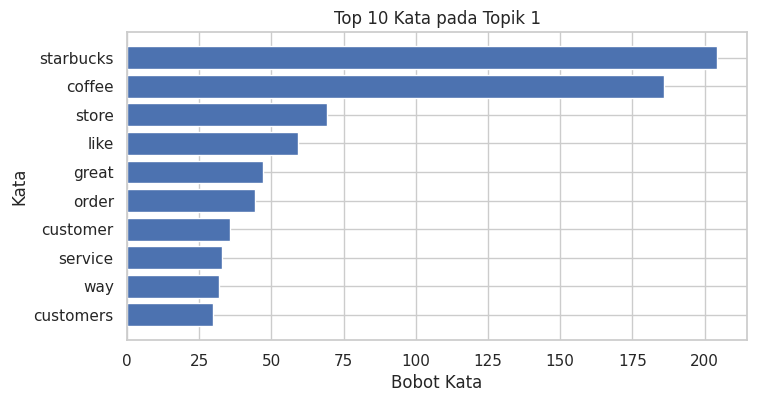


🔹 Topik 2
people          67.43
went            81.12
store           81.22
said            83.34
time            83.96
order           84.35
service         87.41
customer        92.08
coffee          177.15
starbucks       229.02


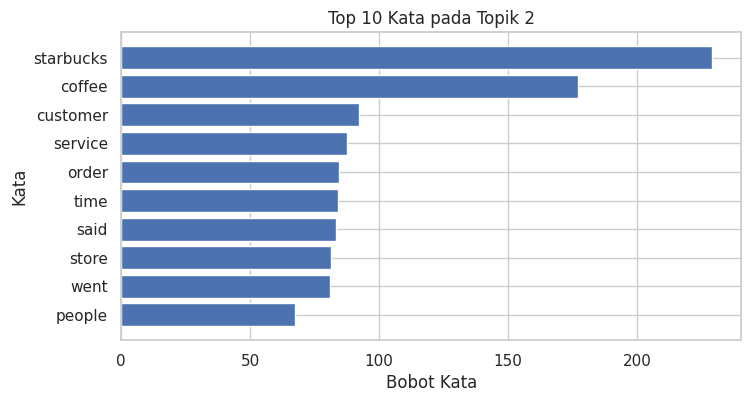


🔹 Topik 3
store           40.01
ordered         44.73
time            47.23
milk            47.88
order           51.00
said            56.71
service         62.52
customer        64.15
drink           112.41
starbucks       135.76


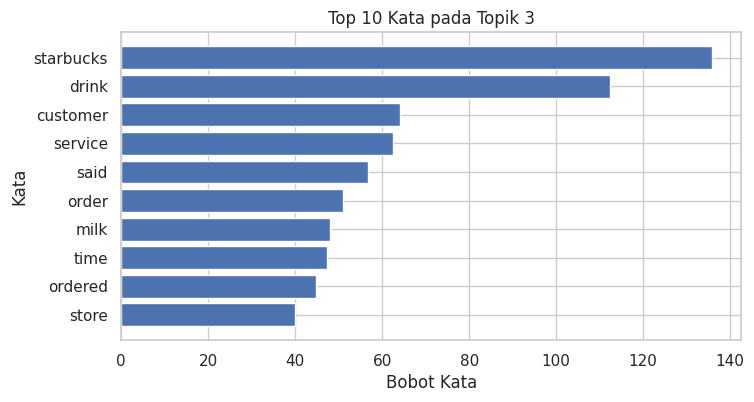


🔹 Topik 4
manager         30.38
make            33.37
cup             34.25
like            34.74
text            36.20
store           37.28
review          41.02
drink           49.66
coffee          92.53
starbucks       129.13


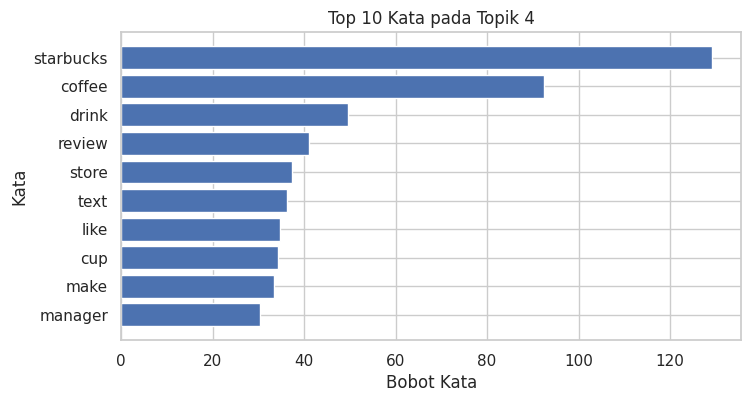


🔹 Topik 5
manager         53.82
went            54.75
money           55.11
service         63.93
time            74.69
told            75.12
customer        85.61
coffee          111.05
card            168.90
starbucks       357.64


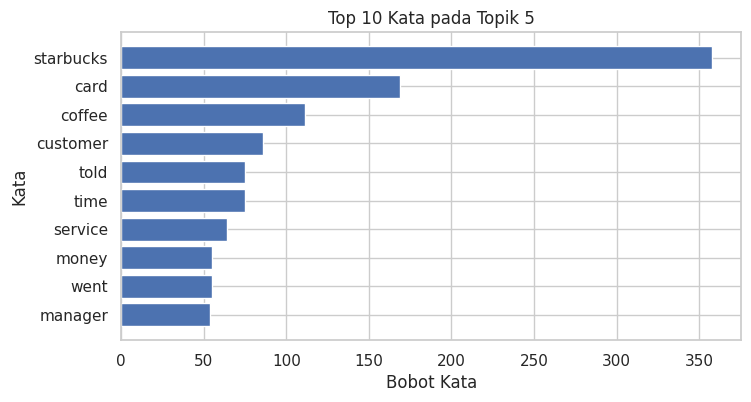

In [35]:
import matplotlib.pyplot as plt

# Ambil kata dan bobot tiap topik
words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda_model.components_):
    print(f"\n🔹 Topik {i+1}")
    top_indices = topic.argsort()[-10:]
    for j in top_indices:
        print(f"{words[j]:<15} {topic[j]:.2f}")

    # Visualisasi Barchart
    plt.figure(figsize=(8, 4))
    plt.barh([words[j] for j in top_indices], topic[top_indices])
    plt.title(f"Top 10 Kata pada Topik {i+1}")
    plt.xlabel("Bobot Kata")
    plt.ylabel("Kata")
    plt.show()


## Gunakan implementasi menggunakan PCA atau T-sne untuk tahap lanjutan

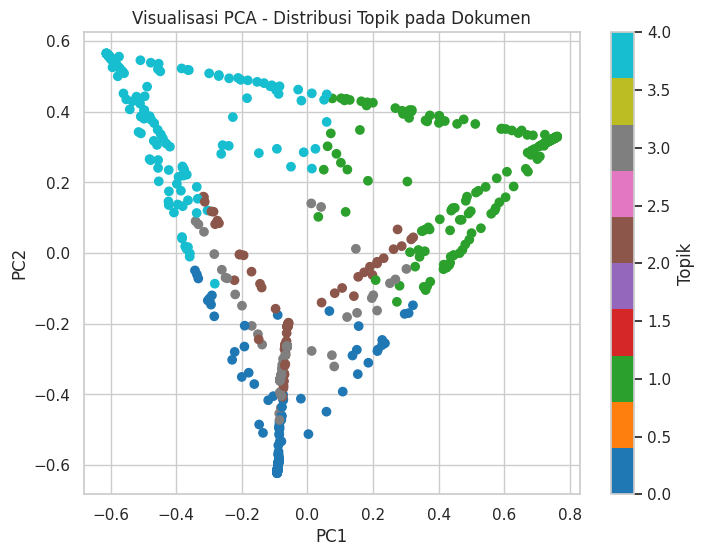

In [36]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Dapatkan representasi topik untuk setiap dokumen
topic_values = lda_model.transform(X)

# Gunakan PCA untuk mereduksi dimensi ke 2D
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(topic_values)

# Visualisasi hasil PCA
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=topic_values.argmax(axis=1), cmap='tab10')
plt.title("Visualisasi PCA - Distribusi Topik pada Dokumen")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Topik")
plt.show()

# Atau bisa pakai t-SNE (lebih detail, tapi lebih lama)
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# tsne_result = tsne.fit_transform(topic_values)
# plt.figure(figsize=(8,6))
# plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=topic_values.argmax(axis=1), cmap='tab10')
# plt.title("Visualisasi t-SNE - Distribusi Topik")
# plt.show()
